# 01 — Israel boundary and GeoParquet bbox pushdown

**Learning objectives:** inspect the exact boundary definition, understand a
rectangle-overlap predicate, and separate candidate pruning from exact
geometry tests.

The study uses the Overture feature satisfying `country='IL'`,
`subtype='country'`, and `is_land=true`. This is an explicit source-data
definition, not a claim about another boundary source.

In [1]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

data_root = Path(os.environ.get("BENCHMARK_DATA_DIR", "/benchmark-data"))
repo_root = Path(
    os.environ.get(
        "BENCHMARK_REPO_DIR",
        Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd(),
    )
)
boundary_path = data_root / "canonical" / "israel_boundary.parquet"
if not boundary_path.exists():
    raise FileNotFoundError("Run ./benchmark.sh prepare boundary first")
boundary = gpd.read_parquet(boundary_path)
boundary[["division_id", "country", "subtype", "is_land"]]

,division_id,country,subtype,is_land
0,bff6e958-3bfc-4f54-9223-19849cc08577,IL,country,True


CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope": "Horiz

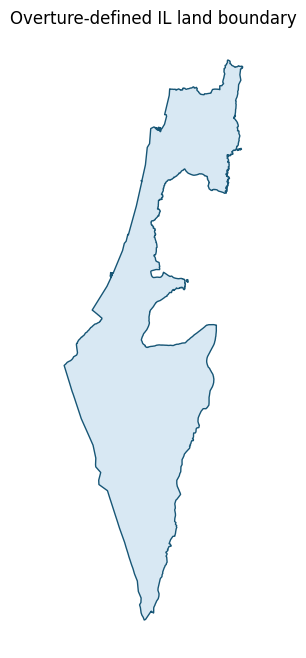

In [2]:
print("CRS:", boundary.crs)
print("Bounds [xmin, ymin, xmax, ymax]:", boundary.total_bounds.tolist())
print("Valid:", bool(boundary.geometry.is_valid.all()))
axis = boundary.plot(facecolor="#d8e8f3", edgecolor="#175676", figsize=(6, 8))
axis.set_title("Overture-defined IL land boundary")
axis.set_axis_off()
plt.show()

## Why four comparisons?

Two rectangles overlap unless one is entirely left, right, above, or below
the other. The positive overlap form is:

```text
road.xmin <= israel.xmax
road.xmax >= israel.xmin
road.ymin <= israel.ymax
road.ymax >= israel.ymin
```

This retains long roads crossing the rectangle even when neither endpoint is
inside it. The exact `ST_Intersects` and clipping steps still decide Israel
membership.

In [3]:
plan = repo_root / "evidence" / "plans" / "bbox-road-scan.txt"
if plan.exists():
    print(plan.read_text()[:5000])
else:
    print("The scan plan is created by the road preparation stage.")

    plan_type                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

**Validation question:** does the plan show the four nested bbox predicates at
the Parquet scan? If not, the output may still be correct, but the required
pruning performance claim has not been demonstrated.